### **Importing BHJet**

In [1]:
from pathlib import Path
import sys

ROOT = Path("/Users/ruby/Desktop/University/phd/bhjet_mod/modBHJet")
sys.path.insert(0, str(ROOT / "python"))

import numpy as np
import matplotlib.pyplot as plt

import bhjet
from bhjet import BLJet, BHJet
# print("Using bhjet from:", bhjet.__file__)

#### **Test that Help Functions Work** (peek into cpp code)

In [2]:
help(bhjet.BLJet)

Help on class BLJet in module bhjet.bhjet:

class BLJet(JetDynamics)
 |  BLJet(*args, **kwargs)
 |
 |  Method resolution order:
 |      BLJet
 |      JetDynamics
 |      builtins.object
 |
 |  Methods defined here:
 |
 |  __init__(...)
 |      __init__(self, mass_bh: float = 1000000000.0, jet_power_eddington: float = 1e-05, z_jet_launching: float = 2.0, r_initial: float = 3.0, z_end_of_acceleration: float = 100000.0, z_dissipation: float = 100.0, z_max_calculation: float = 1000000.0, sigma_final: float = 1.0, gamma_final: float = 15.0, electron_temperature_jet_base: float = 1000.0, gamma_acceleration_exponent: float = 0.5, gamma_deceleration_exponent: float = 0.0, opening_angle_constant: float = 0.15, fraction_nonthermal_electrons: float = 0.1, fraction_nonthermal_protons: float = 0.1, factor_break_electrons: float = 1.0, factor_break_protons: float = 1.0, factor_max_energy_electrons: float = 1.0, factor_max_energy_protons: float = 1.0, index_injected_electrons: float = 2.0, index_inje

#### Initial Setup of Code

Need to start by setting up the dynamic profile of the jet that we want to reproduce (dyn). In this case it's the magnetic driven jet, which is called BLJet. These parameters set up the jet properties, which will set up the jet profile (jet). 

In [3]:
#with hand set parameters: 
mag_jet_dyn = BLJet(
    mass_bh=6e8,
    jet_power_eddington=1e-4,
    z_jet_launching=2,
    r_initial=5,
    z_end_of_acceleration=1e1,
    z_dissipation=50,
    z_max_calculation=1e6,
    sigma_final=1,
    gamma_final=3,
    electron_temperature_jet_base=1e2,
    fraction_nonthermal_electrons=0.1,
    index_injected_electrons=1.8,
    dlgz=0.1,
    verbosity_level=1,
    cutoff_type=2, 
)

In [ ]:
dyn = BLJet(cutoff_type=0) #set up the type of jet profile that we want to use
jet = BHJet() #give it to BHJet

jet.init_jet_dynamics(dyn) #set the intial calculation 
dyn.compute_jet_dynamics()

In [11]:
energy = np.logspace(-11, 10, 200).tolist()
models = {}

for cutoff_type in [0, 1, 2]:
    dyn_i = BLJet(cutoff_type=cutoff_type)
    jet_i = BHJet()
    jet_i.init_jet_dynamics(dyn_i)
    jet_i.compute_full_jet(energy)
    models[cutoff_type] = np.asarray(jet_i.get_observed_photon_flux_total())

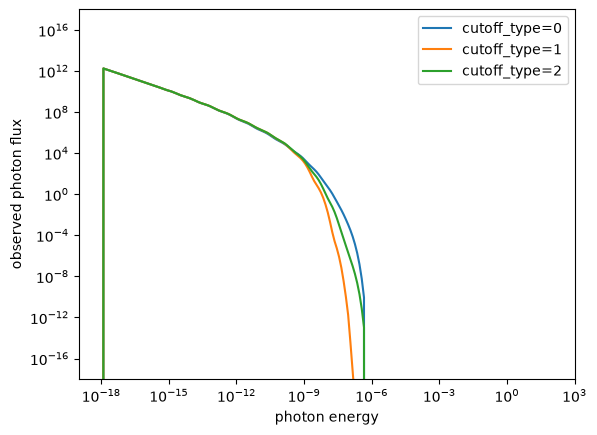

In [ ]:
plt.figure()

for cutoff_type, flux in models.items():
    plt.loglog(energy, flux, label=f"cutoff_type={cutoff_type}")

plt.xlabel("photon energy")
plt.ylabel("observed photon flux")
plt.ylim(1e-18, 1e18)
plt.legend()
plt.show()

In [14]:
dyn = BLJet(cutoff_type=0)
jet = BHJet()
jet.init_jet_dynamics(dyn)

del dyn

jet.compute_full_jet(energy)
f_after_delete = np.asarray(jet.get_observed_photon_flux_total())

print(np.isfinite(f_after_delete).all(), np.any(f_after_delete > 0))

True True


In [5]:
bhjet = BHJet(
    theta_obs=17,
    distance=16e3,     # kpc
    redshift=0.00428,
    include_counterjet=True,
    compton_threshold=1e-5,
    profile_time=True,
    verbosity_level=1,
)
bhjet.init_jet_dynamics(mag_jet_dyn)

In [ ]:
z_min = mag_jet_dyn.r_initial
z_max = mag_jet_dyn.z_max_calculation

In [ ]:
erg2eV = 6.242e+11 # 1erg in eV
eV2erg = 1/erg2eV

E_eV = np.logspace(-8, 19, 200)
bhjet.compute_full_jet(photon_energy_grid=E_eV * eV2erg)

flux = bhjet.get_observed_photon_flux_total()

In [ ]:
plt.loglog(E_eV, E_eV * eV2erg * flux)
plt.xlabel("Observed energy [eV]")
plt.ylabel(r"Observed energy flux [erg cm$^{-2}$ s$^{-1}$]")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
fig, ax = plt.subplots()
# bhjet.set_target_black_body_luminosity("starlight", 1e45)


# ax.loglog(bb_starlight.get_observed_energy()*erg2eV, bb_starlight.get_observed_energy_flux(), label=bb_starlight.name, color="tab:purple")
# Ebb = bhjet.get_observed_photon_energy_grid_black_body("starlight")
# ax.loglog(Ebb*erg2eV, Ebb*bhjet.get_observed_photon_flux_black_body("starlight"), c="tab:purple", label="starlight")

ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    0, mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g), c="tab:blue", label="pre syn")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    0, mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g), c="tab:green", label="pre com")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(
    mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g), c="tab:orange", label="post syn")
ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_compton(
    mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g), c="tab:red", label="post com")

ax.loglog(E_eV, E_eV*eV2erg*bhjet.get_observed_photon_flux_total(), c="k", label="total", ls="--")

ax.legend()
ax.set_xlabel(r"observed energy [eV]")
ax.set_ylabel(r"observed energy flux [erg/(cm²s)]")
ax.set_ylim(1e-19, 1e-5)
ax.set_aspect("equal")
ax.grid(alpha=0.3)

In [ ]:
#returning the flux 
cutoff_zero_syn = E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g)
cutoff_zero_syn

In [ ]:
cutoff_two_syn = E_eV*eV2erg*bhjet.get_observed_photon_integrated_flux_electron_cyclosyn(mag_jet_dyn.z_dissipation*mag_jet_dyn.r_g, mag_jet_dyn.z_max_calculation*mag_jet_dyn.r_g)

In [ ]:
plt.loglog(E_eV, cutoff_zero_syn)
plt.loglog(E_eV, cutoff_two_syn)

#### How to change the shape of the cutoff function: 